In [ ]:
import numpy as np
import pandas as pd

# 只保留sample_6相关的文件
files_sample_6 = [
    "rebuttel/WV3_Reduced/LGPNet/results/model_epoch_370/sample_0.npz",
    "rebuttel/WV3_Reduced/BWNET_LGPNet/results/model_epoch_370/sample_0.npz"
]

# 初始化数据存储
eigenvalues_sample_6 = {file: [] for file in files_sample_6}

# 读取数据并计算特征值
for file in files_sample_6:
    data = np.load(file)
    cov = data['cov'].squeeze()
    # 计算特征值
    eigenvalues_sample_6[file] = np.linalg.eigvals(cov).mean(axis=0)

# 将结果保存为CSV
eigenvalues_combined_sorted = {file: eigenvalues_sample_6[file] for file in eigenvalues_sample_6}

# 创建DataFrame
df = pd.DataFrame(eigenvalues_combined_sorted)
csv_file = "eigenvalues_sample_0.csv"
df.to_csv(csv_file, index=False)

csv_file  # 返回保存的CSV路径


'eigenvalues_sample_0.csv'

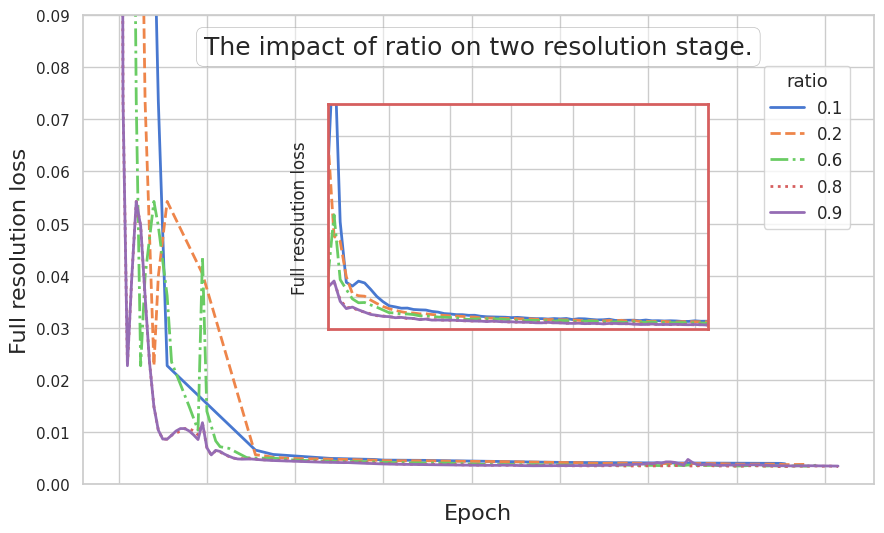

In [225]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.font_manager as fm

# 可选：添加自定义字体
# fm.fontManager.addfont('/home/kndy666/miniconda3/envs/ML/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/times.ttf')
plt.rcParams['font.family'] = 'Times New Roman'

# 读取CSV文件，并指定空值处理
df_full = pd.read_csv("/home/ctz/ZSpan_test/ZSPan/FULL_loss_ratio.csv", na_values=",")
df_rspratio = pd.read_csv("/home/ctz/ZSpan_test/ZSPan/RSPratio_loss.csv", na_values=",")

# 检查是否存在 'Step' 列，否则使用索引作为 x 轴
for df in [df_full, df_rspratio]:
    if 'Step' in df.columns:
        x_col = 'Step'  # 如果存在则使用 'Step'
    else:
        df['Step'] = df.index  # 不存在则将索引添加为 'Step' 列
        x_col = 'Step'

# 设置 Seaborn 样式
sns.set(style="whitegrid", palette="muted")

# 定义不同的线型以便区分
line_styles = ['-', '--', '-.', ':']

# 初始化绘图
fig, ax = plt.subplots(figsize=(9, 5.5))

# 使用 Seaborn 的 lineplot 绘制 'FULL_loss_ratio.csv' 数据的每个列（除 'Step' 外）
for i, column in enumerate(df_full.columns):
    if column != 'Step':
        sns.lineplot(data=df_full, x=x_col, y=column, 
                     label=column, markers='o', markersize=6, linewidth=2, 
                     linestyle=line_styles[i % len(line_styles)], ax=ax)

# 添加标题和标签
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Full resolution loss', fontsize=16)
title = plt.title('The impact of ratio on two resolution stage.', fontsize=18, loc='center', pad=-28)
bbox_props = dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='grey', linewidth=0.5, alpha=0.5)
title.set_bbox(bbox_props)

# 在图中添加放大区域（子图），绘制 'RSPratio_loss.csv' 数据
axin = ax.inset_axes([0.31, 0.33, 0.48, 0.48])  # 创建子图
for i, column in enumerate(df_rspratio.columns):
    if column != 'Step':
        sns.lineplot(data=df_rspratio, x=x_col, y=column, 
                     label=column, markers='o', markersize=6, linewidth=2, 
                     linestyle=line_styles[i % len(line_styles)], ax=axin)

# 子图细节设置：不显示图例与坐标标签
axin.set_yticklabels([])
axin.legend().set_visible(False)
axin.tick_params(left=False, bottom=False, labelbottom=False)
axin.set_xticklabels([])
axin.set_xlabel('')
axin.set_ylabel('Full resolution loss')

# 设置子图的x、y轴范围（独立于主图）
axin.set_xlim(0.00, 62.127)  # 设置子图的x轴范围
axin.set_ylim(0.0000, 0.007)  # 设置子图的y轴范围

# 获取 Seaborn 的主题颜色
theme_color = sns.color_palette("muted")[3]

# 设置子图边框颜色和线宽
for spine in axin.spines.values():
    spine.set_edgecolor(theme_color)
    spine.set_linewidth(2)

# 设置主图纵轴范围为 0 到 0.09
ax.set_ylim(0, 0.09)

# 隐藏主图的 x 轴标签
ax.set_xticklabels([])

# 设置图例位置与属性
ax.legend(title="ratio", fontsize=12, title_fontsize=13, loc='upper left', bbox_to_anchor=(0.85, 0.91))

# 布局调整和保存图像
plt.tight_layout()
plt.savefig("combined_loss_plot.pdf")
plt.show()
